# Feedback control

In [4]:
import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt
from numpy.linalg import norm

Trajectory distance (control vs undisturbed): 0.34715412652363187


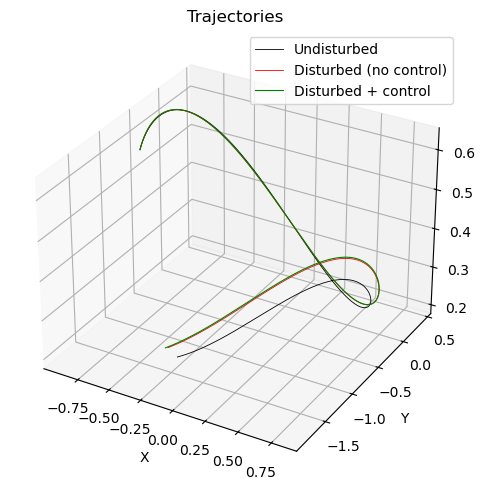

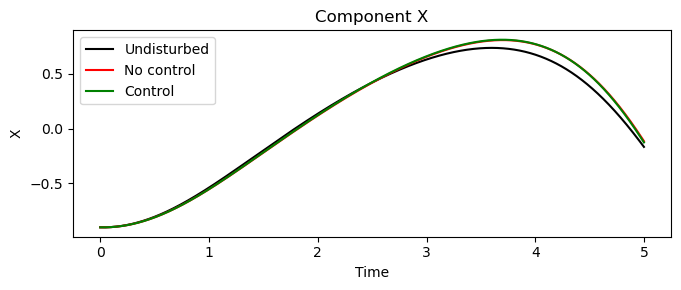

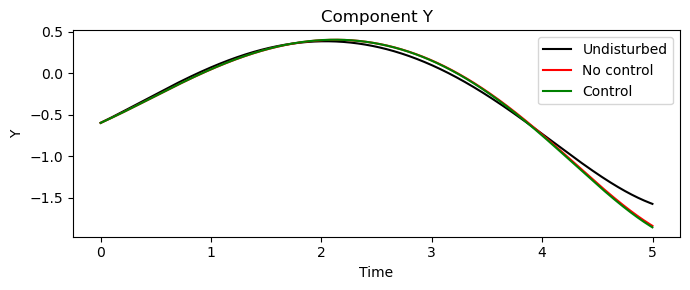

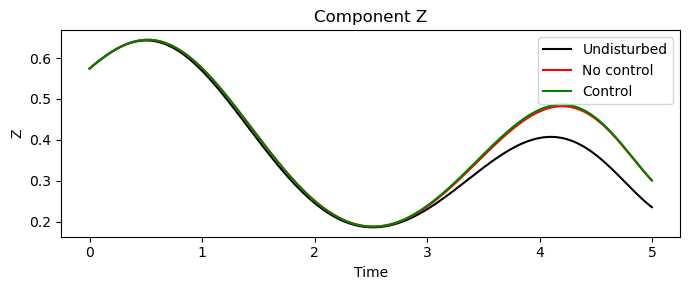

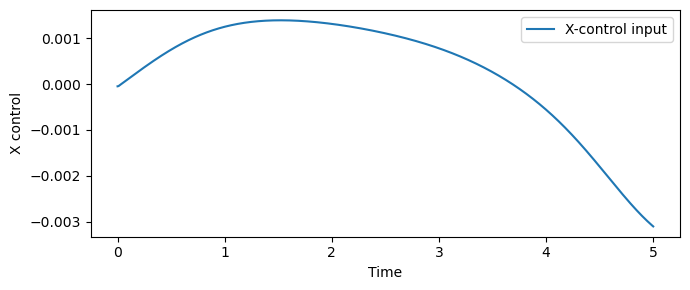

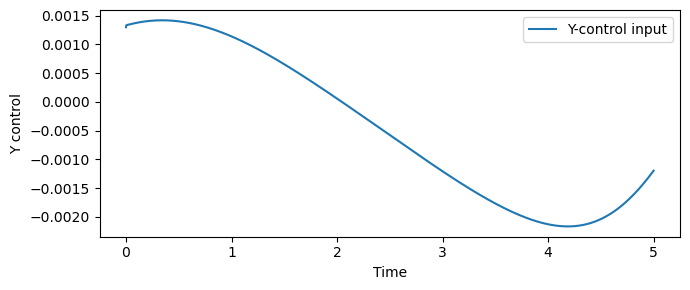

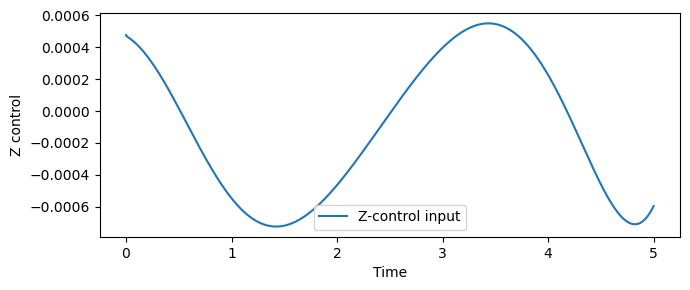

In [6]:
# Shared systems and integrators (aligned with forecast.ipynb)
from dataclasses import dataclass
from typing import Callable, Dict, Tuple, Optional
import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt

# 1) Dynamical systems
def sprott_linz_deriv(x: np.ndarray, params: Dict[str, float]) -> np.ndarray:
    a = params.get('a', 0.42)
    x_, y_, z_ = x
    return np.array([y_ + z_, -x_ + a * y_, x_**2 - z_])

def lorenz_deriv(x: np.ndarray, params: Dict[str, float]) -> np.ndarray:
    sigma = params.get('sigma', 10.0)
    rho   = params.get('rho', 28.0)
    beta  = params.get('beta', 8.0/3.0)
    x_, y_, z_ = x
    return np.array([sigma * (y_ - x_), x_ * (rho - z_) - y_, x_ * y_ - beta * z_])

def get_system(system_name: str) -> Tuple[Callable[[np.ndarray, Dict[str,float]], np.ndarray], Dict[str, float]]:
    name = system_name.lower()
    if name in ['sprott-linz', 'sprott_linz', 'sprott']:
        return sprott_linz_deriv, {'a': 0.42}
    if name in ['lorenz', 'lorenz63']:
        return lorenz_deriv, {'sigma': 10.0, 'rho': 28.0, 'beta': 8.0/3.0}
    raise ValueError(f"Unknown system '{system_name}'. Use 'sprott-linz' or 'lorenz'.")

# 2) Integrators
def euler_step(f: Callable[[np.ndarray, Dict[str,float]], np.ndarray], x: np.ndarray, dt: float, params: Dict[str,float]) -> np.ndarray:
    return x + dt * f(x, params)

def rk4_step(f: Callable[[np.ndarray, Dict[str,float]], np.ndarray], x: np.ndarray, dt: float, params: Dict[str,float]) -> np.ndarray:
    k1 = f(x, params)
    k2 = f(x + 0.5 * dt * k1, params)
    k3 = f(x + 0.5 * dt * k2, params)
    k4 = f(x + dt * k3, params)
    return x + (dt/6.0)*(k1 + 2*k2 + 2*k3 + k4)

def get_stepper(method: str):
    method = method.lower()
    if method == 'euler':
        return euler_step
    if method in ['rk4', 'runge-kutta', 'rk']:
        return rk4_step
    raise ValueError("Integrator must be 'euler' or 'rk4'.")
    
# 3) Reservoir and training (aligned with forecast.ipynb)
@dataclass
class Reservoir:
    A: sp.csr_matrix
    Win: np.ndarray
    bias: float

def build_reservoir(n: int, m: int, spectral_radius: float = 1.2, density: float = 6.0, input_scale: float = 0.1,
                     bias: float = 1.0, seed: Optional[int] = None) -> Reservoir:
    rng = np.random.default_rng(seed)
    A_rand = sp.random(n, n, density=density/n, format='csr', random_state=seed)
    A_data = A_rand.toarray()
    A_data = A_data - 0.5 * np.sign(A_data)
    A_temp = sp.csr_matrix(A_data)
    eigvals = sp.linalg.eigs(A_temp, k=1, which='LR', return_eigenvectors=False)
    A_scaled = A_temp * (spectral_radius / np.abs(eigvals[0]))
    Win = input_scale*(2.0 * rng.random((n, m)) - 1.0)
    return Reservoir(A=A_scaled.tocsr(), Win=Win, bias=bias)

def train_reservoir(deriv: Callable, params: Dict[str,float], reservoir: Reservoir, x0: np.ndarray,
                    T: float, dt: float, lam: float = 1e-4, washout: int = 1000,
                    integrator: str = 'rk4', seed: Optional[int] = None) -> Dict[str, np.ndarray]:
    stepper = get_stepper(integrator)
    n_steps = int(T / dt)
    m = len(x0)
    n = reservoir.A.shape[0]
    rng = np.random.default_rng(seed)
    R = np.zeros((n, n_steps))
    F = np.zeros((m, n_steps))
    r = 2.0 * rng.random(n) - 1.0
    x = x0.copy()
    for t in range(n_steps):
        u = x.copy()
        R[:, t] = r
        F[:, t] = u
        x = stepper(deriv, x, dt, params)
        r = np.tanh(reservoir.A.dot(r) + reservoir.Win.dot(u) + reservoir.bias)
    if washout >= n_steps:
        raise ValueError("Washout >= total steps; reduce washout or increase T.")
    R_eff = R[:, washout:]
    F_eff = F[:, washout:]
    Id = np.eye(n)
    Wout = F_eff.dot(R_eff.T).dot(np.linalg.inv(R_eff.dot(R_eff.T) + lam * Id))
    return {'Wout': Wout, 'x_last': x, 'r_last': r}

# 4) Feedback control simulation
from typing import List

def apply_percentage_disturbance(params: Dict[str,float], disturb_pct: float, key: str) -> Dict[str,float]:
    newp = dict(params)
    newp[key] = params[key] * (1.0 + disturb_pct/100.0)
    return newp

def trajectory_shortest_distance(true: np.ndarray, pred: np.ndarray, n_samples: int = 100, seed: Optional[int] = None) -> float:
    T_pred = pred.shape[1]
    if T_pred == 0:
        return float('nan')
    n_eff = min(n_samples, T_pred)
    rng = np.random.default_rng(seed)
    idxs = rng.choice(T_pred, size=n_eff, replace=False)
    total = 0.0
    for idx in idxs:
        p = pred[:, idx][:, None]
        dists = np.linalg.norm(true - p, axis=0)
        total += float(dists.min())
    return total / n_eff

def simulate_feedback(
    system_name: str = 'sprott-linz',
    system_params: Optional[Dict[str,float]] = None,
    disturb_key: Optional[str] = None,
    disturb_pct: float = 0.0,
    training_time: float = 300.0,
    forecast_time: float = 50.0,
    dt: float = 0.002,
    reservoir_size: int = 500,
    spectral_radius: float = 1.2,
    density: float = 6.0,
    input_scale: float = 0.1,
    bias: float = 1.0,
    lam: float = 1e-4,
    washout: int = 1000,
    integrator: str = 'rk4',
    seed: int = 42,
    control_gain: float = 1.0,
) -> Dict[str, np.ndarray]:
    deriv, default_params = get_system(system_name)
    if system_params:
        default_params.update(system_params)
    params_nominal = default_params

    # Choose which parameter to disturb if not provided
    if disturb_key is None:
        disturb_key = next(iter(params_nominal.keys()))
    params_disturbed = apply_percentage_disturbance(params_nominal, disturb_pct, disturb_key)

    # Build reservoir and train on nominal system
    rng = np.random.default_rng(seed)
    x0 = rng.random(3) - 0.5
    reservoir = build_reservoir(n=reservoir_size, m=3, spectral_radius=spectral_radius, density=density,
                                input_scale=input_scale, bias=bias, seed=seed)
    tr = train_reservoir(deriv, params_nominal, reservoir, x0, T=training_time, dt=dt, lam=lam,
                         washout=washout, integrator=integrator, seed=seed)

    # Parallel simulation of three systems over forecast_time
    n_steps = int(forecast_time / dt)
    times = np.linspace(0.0, forecast_time, n_steps)

    # State arrays (dims, T)
    undist = np.zeros((3, n_steps))
    noctrl = np.zeros((3, n_steps))
    ctrl   = np.zeros((3, n_steps))

    # Keep track of control inputs and reservoir target
    targets = np.zeros((3, n_steps))
    control_inputs = np.zeros((3, n_steps))

    # Initial states
    x_u = tr['x_last'].copy()
    x_n = tr['x_last'].copy()
    x_c = tr['x_last'].copy()

    # Reservoir state for controller
    r = tr['r_last'].copy()

    stepper = get_stepper(integrator)

    for t in range(n_steps):
        # Log current states
        undist[:, t] = x_u
        noctrl[:, t] = x_n
        ctrl[:, t]   = x_c

        # Advance undisturbed system
        x_u = stepper(deriv, x_u, dt, params_nominal)

        # Advance disturbed system without control
        x_n = stepper(deriv, x_n, dt, params_disturbed)

        # Feedback control path: use reservoir predicted target to drive disturbed towards target
        r = np.tanh(reservoir.A.dot(r) + reservoir.Win.dot(x_c) + reservoir.bias)
        target = tr['Wout'].dot(r)  # predicted next state (trained on nominal)
        u = control_gain * (target - x_c)

        # Store control info
        targets[:, t] = target
        control_inputs[:, t] = u

        # Disturbed dynamics with control input
        f_c = deriv(x_c, params_disturbed)
        x_c = x_c + dt * (f_c + u)

    # Metric: distance between controlled trajectory and undisturbed nominal trajectory
    dist = trajectory_shortest_distance(undist, ctrl, n_samples=200, seed=seed)

    return {
        'times': times,
        'undisturbed': undist,
        'disturbed_no_control': noctrl,
        'disturbed_control': ctrl,
        'targets': targets,
        'control_inputs': control_inputs,
        'control_distance_metric': np.array([dist]),
        'params_nominal': params_nominal,
        'params_disturbed': params_disturbed,
        'disturbance_key': np.array([disturb_key], dtype=object),
        'disturbance_pct': np.array([disturb_pct]),
    }
    
# 5) Plotting utilities
from typing import Tuple

def plot_feedback_results(results: Dict[str, np.ndarray], from_time: float = 0.0, to_time: Optional[float] = None):
    times = results['times']
    und  = results['undisturbed']
    noc  = results['disturbed_no_control']
    ctr  = results['disturbed_control']

    if to_time is None:
        to_time = float(times[-1])
    mask = (times >= from_time) & (times <= to_time)
    t = times[mask]
    und_sel, noc_sel, ctr_sel = und[:, mask], noc[:, mask], ctr[:, mask]

    # 3D trajectories
    fig = plt.figure(figsize=(6, 5))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot(und_sel[0], und_sel[1], und_sel[2], 'k', lw=0.6, label='Undisturbed')
    ax.plot(noc_sel[0], noc_sel[1], noc_sel[2], 'r', lw=0.6, label='Disturbed (no control)')
    ax.plot(ctr_sel[0], ctr_sel[1], ctr_sel[2], 'g', lw=0.8, label='Disturbed + control')
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    ax.set_title('Trajectories')
    ax.legend(); plt.tight_layout()

    comps = ['X','Y','Z']
    for i in range(3):
        plt.figure(figsize=(7, 3))
        plt.plot(t, und_sel[i], 'k', label='Undisturbed')
        plt.plot(t, noc_sel[i], 'r', label='No control')
        plt.plot(t, ctr_sel[i], 'g', label='Control')
        plt.xlabel('Time'); plt.ylabel(comps[i])
        plt.title(f'Component {comps[i]}')
        plt.legend(); plt.tight_layout()


def plot_control_inputs(times: np.ndarray, ctrl_states: np.ndarray, targets: np.ndarray, from_time: float = 0.0, to_time: Optional[float] = None, gain: float = 1.0):
    if to_time is None:
        to_time = float(times[-1])
    mask = (times >= from_time) & (times <= to_time)
    t = times[mask]
    err = (targets - ctrl_states)[:, mask]
    u = gain * err
    comps = ['X','Y','Z']
    for i in range(3):
        plt.figure(figsize=(7, 3))
        plt.plot(t, u[i], label=f'{comps[i]}-control input')
        plt.xlabel('Time'); plt.ylabel(f'{comps[i]} control')
        plt.legend(); plt.tight_layout()

# 6) Parameters and demo run
system_name = 'sprott-linz'   # 'sprott-linz' or 'lorenz'
system_params = None          # e.g., {'a': 0.42} or {'rho': 30.0}

training_time = 120.0
forecast_time = 20.0
dt = 0.002

reservoir_size = 400
spectral_radius = 1.2
density = 6.0
input_scale = 0.1
bias = 1.0
lam = 1e-4
washout = 800
integrator = 'rk4'
seed = 123
control_gain = 1.0

# Disturbance configuration (percentage on a chosen parameter key)
disturb_key = None       # if None, will pick first parameter key by default
disturb_pct = 20.0       # e.g., 20% increase on that parameter

res = simulate_feedback(
    system_name=system_name,
    system_params=system_params,
    disturb_key=disturb_key,
    disturb_pct=disturb_pct,
    training_time=training_time,
    forecast_time=forecast_time,
    dt=dt,
    reservoir_size=reservoir_size,
    spectral_radius=spectral_radius,
    density=density,
    input_scale=input_scale,
    bias=bias,
    lam=lam,
    washout=washout,
    integrator=integrator,
    seed=seed,
    control_gain=control_gain,
)

print('Trajectory distance (control vs undisturbed):', float(res['control_distance_metric'][0]))
plot_feedback_results(res, from_time=0.0, to_time=min(5.0, float(res['times'][-1])))

# 7) Plot control inputs
plot_control_inputs(res['times'], res['disturbed_control'], res['targets'], from_time=0.0, to_time=min(5.0, float(res['times'][-1])), gain=control_gain)